In [2]:
import dowhy
from dowhy import CausalModel
import pandas as pd
import numpy as np

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

study_time = np.random.normal(5, 2, n)
sleep = np.random.normal(7, 1.5, n)
prior_ability = np.random.normal(70, 10, n)

# Probability of drinking coffee depends on confounders
logit_p = (
    -1
    + 0.3 * study_time
    - 0.4 * sleep
    + 0.02 * prior_ability
)

p_coffee = 1 / (1 + np.exp(-logit_p))
coffee = np.random.binomial(1, p_coffee)

# Mediator
alertness = (
    5
    + 2 * coffee
    + 0.3 * sleep
    + np.random.normal(0, 1, n)
)

# Outcome
score = (
    40
    + 2.5 * coffee
    + 4 * study_time
    + 2 * sleep
    + 0.5 * prior_ability
    + 1.5 * alertness
    + np.random.normal(0, 5, n)
)

df = pd.DataFrame({
    "coffee": coffee,
    "score": score,
    "study_time": study_time,
    "sleep": sleep,
    "prior_ability": prior_ability,
    "alertness": alertness
})

df.head()

,coffee,score,study_time,sleep,prior_ability,alertness
0,0,115.210533,5.993428,9.099033,63.248217,7.910773
1,1,127.822947,4.723471,8.386951,68.554813,10.819363
2,0,120.639776,6.295377,7.089446,62.075801,7.712999
3,0,125.298927,8.046060,6.029595,66.920385,6.396465
4,0,110.687265,4.531693,8.047335,51.063853,7.671399


In [4]:
df.groupby("coffee")["score"].mean()

coffee
0    118.826600
1    127.906827
Name: score, dtype: float64

In [5]:
naive_difference = (
    df[df["coffee"] == 1]["score"].mean()
    - df[df["coffee"] == 0]["score"].mean()
)

print(naive_difference)

9.080226992369418


In [6]:
graph = """
digraph {
    study_time -> coffee;
    study_time -> score;

    sleep -> coffee;
    sleep -> score;

    prior_ability -> coffee;
    prior_ability -> score;

    coffee -> alertness;
    alertness -> score;

    coffee -> score;
}
"""

In [7]:
from dowhy import CausalModel

model = CausalModel(
    data=df,
    treatment="coffee",
    outcome="score",
    graph=graph
)

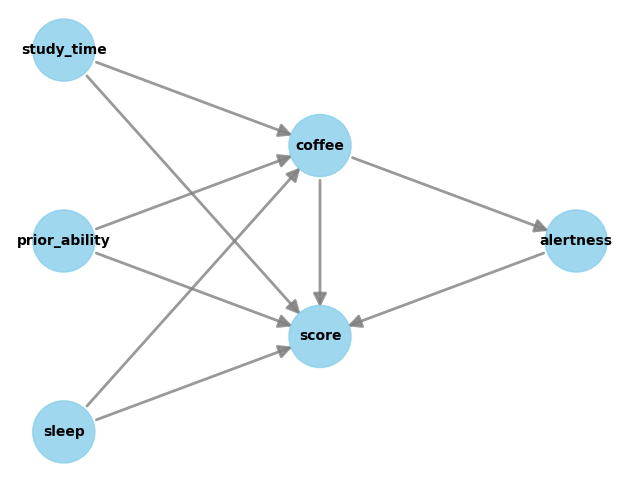

In [8]:
model.view_model()

In [9]:
identified_estimand = model.identify_effect()

print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                             
─────────(E[score|sleep,prior_ability,study_time])
d[coffee]                                         
Estimand assumption 1, Unconfoundedness: If U→{coffee} and U→score then P(score|coffee,sleep,prior_ability,study_time,U) = P(score|coffee,sleep,prior_ability,study_time)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
    d                                             
─────────(E[score|sleep,prior_ability,study_time])
d[coffee]                                         
Estimand assumption 1, Unconfoundedness: If U→{coffee} and U→score then P(score|coffee,sleep,prior_ability,study_time,U) = P(score|coffee,sleep,prior_ability,study_time)



In [10]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

print(estimate)
print("Estimated causal effect:", estimate.value)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                             
─────────(E[score|sleep,prior_ability,study_time])
d[coffee]                                         
Estimand assumption 1, Unconfoundedness: If U→{coffee} and U→score then P(score|coffee,sleep,prior_ability,study_time,U) = P(score|coffee,sleep,prior_ability,study_time)

## Realized estimand
b: score~coffee+sleep+prior_ability+study_time
Target units: ate

## Estimate
Mean value: 5.329332761240366

Estimated causal effect: 5.329332761240366


In [11]:
import statsmodels.api as sm

X_wrong = df[["coffee", "study_time", "sleep", "prior_ability", "alertness"]]
X_wrong = sm.add_constant(X_wrong)

wrong_model = sm.OLS(df["score"], X_wrong).fit()

print(wrong_model.summary())
print("Coffee coefficient when controlling for alertness:", wrong_model.params["coffee"])

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     912.0
Date:                Thu, 28 May 2026   Prob (F-statistic):               0.00
Time:                        12:47:40   Log-Likelihood:                -3009.1
No. Observations:                1000   AIC:                             6030.
Df Residuals:                     994   BIC:                             6060.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            41.0565      1.592     25.785

In [12]:
estimate_matching = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching"
)

print(estimate_matching)
print("Matching estimate:", estimate_matching.value)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                             
─────────(E[score|sleep,prior_ability,study_time])
d[coffee]                                         
Estimand assumption 1, Unconfoundedness: If U→{coffee} and U→score then P(score|coffee,sleep,prior_ability,study_time,U) = P(score|coffee,sleep,prior_ability,study_time)

## Realized estimand
b: score~coffee+sleep+prior_ability+study_time
Target units: ate

## Estimate
Mean value: 5.297919971105913

Matching estimate: 5.297919971105913


In [13]:
estimate_ipw = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting"
)

print(estimate_ipw)
print("IPW estimate:", estimate_ipw.value)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                             
─────────(E[score|sleep,prior_ability,study_time])
d[coffee]                                         
Estimand assumption 1, Unconfoundedness: If U→{coffee} and U→score then P(score|coffee,sleep,prior_ability,study_time,U) = P(score|coffee,sleep,prior_ability,study_time)

## Realized estimand
b: score~coffee+sleep+prior_ability+study_time
Target units: ate

## Estimate
Mean value: 5.81701351180152

IPW estimate: 5.81701351180152


In [14]:
refute_random = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause"
)

print(refute_random)

Refute: Add a random common cause
Estimated effect:5.329332761240366
New effect:5.3311619131082075
p value:0.8799999999999999



In [15]:
refute_placebo = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter"
)

print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:5.329332761240366
New effect:0.00898552872046153
p value:0.96



In [16]:
refute_subset = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="data_subset_refuter"
)

print(refute_subset)

Refute: Use a subset of data
Estimated effect:5.329332761240366
New effect:5.3313543280332825
p value:0.96

